In [1]:
import json
import pandas as pd
import numpy as np
import os
from PIL import Image
import uuid

In [2]:

# Set pandas options to display all rows and all columns
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)



df_multiple = pd.read_csv('df_count_all_num_images_cleaned.csv')
df_multiple.drop(columns=['Status', 'สแกนแล้ว', 'Note', 'Link', 'Remark', 'Humidity', 'Weight'],inplace=True)

In [3]:
# df_multiple[df_multiple['Breed'] == 'GK79']['num_image'].sum()
# df_multiple[df_multiple['keys_img_id_ac'] == '000198_0000369']

In [3]:

def merge_json_with_df(df_multiple, json_metadata_path, selected_split="train"):
    """
    Merges image-level JSON metadata with the folder-level DataFrame.
    
    Steps:
      1. Loads JSON metadata (each record includes 'folder_key' and 'split').
      2. Filters the metadata to include only records from the selected split.
      3. Computes the total number of images per folder from the filtered metadata.
      4. Merges these folder-level attributes (such as 'Breed', 'Year', and 'total_images') into the metadata.
      5. Assigns a new local index ("local_image_index") for each image within its folder,
         which will be used to index the numpy images stored in each npz file.
    
    Parameters:
      df_multiple (pd.DataFrame): Folder-level DataFrame with columns like 'keys_img_id_ac', 'Breed', 'Year', etc.
      json_metadata_path (str): Path to the JSON file containing image-level metadata.
      selected_split (str): The split to select (e.g., "train").
    
    Returns:
      pd.DataFrame: Merged DataFrame with image-level metadata, folder-level attributes, and a new local image index.
    """
    with open(json_metadata_path, 'r') as f:
        metadata_records = json.load(f)
    metadata_df = pd.DataFrame(metadata_records)
    
    # Filter metadata to only include the selected split (e.g., "train")
    metadata_df = metadata_df[metadata_df['split'] == selected_split]
    
    # Compute total_images per folder from the filtered metadata
    total_images_df = metadata_df.groupby('folder_key').size().reset_index(name='total_images')
    
    # Merge total_images into df_multiple using folder key matching
    df_multiple_updated = df_multiple.merge(total_images_df, left_on='keys_img_id_ac', 
                                            right_on='folder_key', how='left')
    df_multiple_updated.drop(columns=['folder_key'], inplace=True)
    
    # Merge the filtered image-level metadata with the folder-level attributes
    merged_df = metadata_df.merge(df_multiple_updated, left_on='folder_key', 
                                  right_on='keys_img_id_ac', how='left')
    
    # Assign a new local index per folder to indicate the image position within the npz file.
    merged_df['local_image_index'] = merged_df.groupby('keys_img_id_ac').cumcount()
    
    return merged_df

def balance_by_Breed_year_split(df_subset, random_state=42):
    """
    Balances a subset of data (for one binary class) in two layers:
      1. Within each Breed, balance across Years:
         - For each Breed, group the data by Year.
         - Compute the total number of images per Year.
         - Use the average total as the target weight.
         - Downsample each Year group proportionally (without upsampling) so that every year contributes roughly equally.
      2. Across Breeds, balance by downsampling each Breed to the size of the smallest group.
    
    Parameters:
      df_subset (pd.DataFrame): Subset of data corresponding to one binary class (0 or 1).
      random_state (int): Seed for reproducibility.
      
    Returns:
      pd.DataFrame: Balanced DataFrame for the given binary class.
    """
    balanced_Breed_groups = []
    
    # Group data by Breed.
    for Breed, Breed_group in df_subset.groupby('Breed'):
        # Group by Year within each Breed.
        year_groups = {year: group for year, group in Breed_group.groupby('Year')}
        # Compute total_images for each year.
        total_images_by_year = {year: grp['total_images'].sum() for year, grp in year_groups.items()}
        # Use the average total as the target weight.
        target_total = np.mean(list(total_images_by_year.values()))
        
        balanced_year_samples = []
        for year, grp in year_groups.items():
            group_total = total_images_by_year[year]
            # Compute sampling fraction, capped at 1.0 (i.e. no upsampling)
            frac = target_total / group_total if group_total > 0 else 1.0
            frac = min(frac, 1.0)
            n_to_sample = int(round(len(grp) * frac))
            n_to_sample = max(n_to_sample, 1) if len(grp) > 0 else 0
            balanced_year_samples.append(grp.sample(n=n_to_sample, random_state=random_state))
        
        Breed_balanced = pd.concat(balanced_year_samples)
        balanced_Breed_groups.append(Breed_balanced)
    
    if balanced_Breed_groups:
        # Balance across Breeds by downsampling to the smallest group.
        min_count = min(len(g) for g in balanced_Breed_groups)
        balanced_across_Breeds = [g.sample(n=min_count, random_state=random_state) for g in balanced_Breed_groups]
        return pd.concat(balanced_across_Breeds)
    else:
        return df_subset



def prepare_dataset_json_multi_class(merged_df, class_groups, total_samples=None, selected_split="train", random_state=42):
    df = merged_df.copy()

    # Filter by selected split
    if selected_split:
        df = df[df['split'] == selected_split]

    # Assign new multi-class labels based on class_groups
    def assign_class_label(breed):
        for class_idx, breed_group in enumerate(class_groups):
            if breed in breed_group:
                return class_idx
        return None

    df['class_label'] = df['Breed'].apply(assign_class_label)
    df = df.dropna(subset=['class_label'])

    balanced_subsets = []
    for class_label in sorted(df['class_label'].unique()):
        subset = df[df['class_label'] == class_label]
        if not subset.empty:
            balanced_subset = balance_by_Breed_year_split(subset, random_state=random_state)
            balanced_subsets.append(balanced_subset)

    final_df = pd.concat(balanced_subsets, ignore_index=True)

    additional_samples_list = []  # to collect additional samples per class

    if total_samples:
        num_classes = len(balanced_subsets)
        target_per_class = total_samples // num_classes

        balanced_final = []

        for class_label in range(num_classes):
            class_df = final_df[final_df['class_label'] == class_label]
            available_samples = len(class_df)

            print(f"Class {class_label}: Available samples before balancing: {available_samples}")

            if available_samples < target_per_class:
                missing = target_per_class - available_samples
                print(f"Class {class_label} short of {missing} samples")

                # Restrict additional sampling to this class only.
                class_pool = df[df['class_label'] == class_label]
                # Exclude samples already present in class_df.
                class_pool = class_pool.loc[~class_pool.index.isin(class_df.index)]

                # If the available additional samples are fewer than needed,
                # add only one extra sample (if available) to avoid duplicates.
                if len(class_pool) < missing:
                    print(f"Warning: Not enough additional samples available for class {class_label}. Adding only one additional sample.")
                    additional_for_class = class_pool.sample(n=1, random_state=random_state) if len(class_pool) > 0 else class_pool
                else:
                    additional_for_class = class_pool.sample(n=missing, random_state=random_state)

                combined_class = pd.concat([class_df, additional_for_class])
                balanced_final.append(combined_class)
                additional_samples_list.append(additional_for_class)
            else:
                balanced_final.append(class_df.sample(n=target_per_class, random_state=random_state))

        final_df = pd.concat(balanced_final, ignore_index=True)

    additional_samples = pd.concat(additional_samples_list, ignore_index=True) if additional_samples_list else None

    return final_df, additional_samples










def split_train_valid_intra_group(df, group_column='keys_img_id_ac', valid_fraction=0.2, random_state=42):
    """
    Splits the DataFrame into training and validation sets by splitting within each group (keys_img_id_ac).
    This ensures that every group (folder) appears in both train and valid splits.
    
    Parameters:
      df (pd.DataFrame): The balanced DataFrame.
      group_column (str): Column representing the group (e.g., keys_img_id_ac).
      valid_fraction (float): Fraction of images within each group to assign to validation.
      random_state (int): Seed for reproducibility.
    
    Returns:
      (pd.DataFrame, pd.DataFrame): Tuple of (train_df, valid_df)
    """
    np.random.seed(random_state)
    train_list = []
    valid_list = []
    
    # Process each group (each folder) individually.
    for key, group in df.groupby(group_column):
        group = group.copy()
        n = len(group)
        
        # Create a boolean mask to assign samples to valid.
        # For each sample, decide randomly if it goes to valid.
        # We use np.random.rand(n) and compare with valid_fraction.
        mask = np.random.rand(n) < valid_fraction
        
        # To ensure that each group contributes to both splits when possible:
        if n > 1:
            # If all samples were assigned to valid, force one sample into train.
            if mask.all():
                random_index = np.random.choice(n)
                mask[random_index] = False
            # If none were assigned to valid, force one sample into valid.
            elif not mask.any():
                random_index = np.random.choice(n)
                mask[random_index] = True
        
        # Append the split group.
        valid_list.append(group[mask])
        train_list.append(group[~mask])
    
    train_df = pd.concat(train_list).reset_index(drop=True)
    valid_df = pd.concat(valid_list).reset_index(drop=True)
    
    # Mark the splits in a new column (optional).
    train_df['new_split'] = 'train'
    valid_df['new_split'] = 'valid'
    
    return train_df, valid_df





json_metadata_path = '/media/nas/MP/hovernet/Split_Processed/dataset_split_metadata.json'
merged_df = merge_json_with_df(df_multiple, json_metadata_path, selected_split="train")


# class_groups = [['ML105', 'GK15'], ['GK79'], ['GK6'],['PT1'],['PL80'],['CN1'],['SPT1']]
class_groups = (merged_df['Breed'].unique()).tolist()


In [4]:

final_balanced_df,additional_samples = prepare_dataset_json_multi_class(
    merged_df,
    class_groups=class_groups,
    total_samples=450000,
    selected_split="train",
    random_state=42
)

train_df, valid_df = split_train_valid_intra_group(
    final_balanced_df,
    group_column='keys_img_id_ac',
    valid_fraction=0.2,
    random_state=42
)

print("Final train samples:", len(train_df))
print("Final validation samples:", len(valid_df))


Class 0: Available samples before balancing: 185922
Class 1: Available samples before balancing: 70114
Class 2: Available samples before balancing: 41372
Class 3: Available samples before balancing: 21916
Class 4: Available samples before balancing: 47299
Class 5: Available samples before balancing: 8512
Class 5 short of 311 samples
Class 6: Available samples before balancing: 13500
Class 7: Available samples before balancing: 38704
Class 8: Available samples before balancing: 20704
Class 9: Available samples before balancing: 32694
Class 10: Available samples before balancing: 28114
Class 11: Available samples before balancing: 14115
Class 12: Available samples before balancing: 38968
Class 13: Available samples before balancing: 26653
Class 14: Available samples before balancing: 14432
Class 15: Available samples before balancing: 21044
Class 16: Available samples before balancing: 0
Class 16 short of 8823 samples
Class 17: Available samples before balancing: 9396
Class 18: Available

In [5]:
print("Unique keys in train:", len(train_df['keys_img_id_ac'].unique()))
print("Unique keys in valid:", len(valid_df['keys_img_id_ac'].unique()))

Unique keys in train: 377
Unique keys in valid: 377


In [6]:
train_df

,folder_key,npz_file,image_in_file_index,global_index,split,Unnamed: 0.1,Unnamed: 0,ID,ActivityID,Lot,...,Source_Type,Province,Use_Case,keys_img_id_ac,num_image,Year,total_images,local_image_index,class_label,new_split
0,000023_0000003,000023_0000003_0057.npz,947,947,train,2,2,23,3,20210608,...,CNTB,Surin,Train,000023_0000003,1104,2021,883,760,0,train
1,000023_0000003,000023_0000003_0057.npz,376,376,train,2,2,23,3,20210608,...,CNTB,Surin,Train,000023_0000003,1104,2021,883,299,0,train
2,000023_0000003,000023_0000003_0057.npz,579,579,train,2,2,23,3,20210608,...,CNTB,Surin,Train,000023_0000003,1104,2021,883,468,0,train
3,000023_0000003,000023_0000003_0057.npz,953,953,train,2,2,23,3,20210608,...,CNTB,Surin,Train,000023_0000003,1104,2021,883,765,0,train
4,000023_0000003,000023_0000003_0057.npz,500,500,train,2,2,23,3,20210608,...,CNTB,Surin,Train,000023_0000003,1104,2021,883,399,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353075,000828_0001545,000828_0001545_GK61_SC3135_20250122_0011.npz,67,5070,train,1416,1545,828,1545,20241219,...,CNTB,Phichit,Train,000828_0001545,22230,2024,17784,4064,7,train
353076,000828_0001545,000828_0001545_GK61_SC3135_20250122_0014.npz,417,6925,train,1416,1545,828,1545,20241219,...,CNTB,Phichit,Train,000828_0001545,22230,2024,17784,5537,7,train
353077,000828_0001545,000828_0001545_GK61_SC3135_20250122_0045.npz,327,22072,train,1416,1545,828,1545,20241219,...,CNTB,Phichit,Train,000828_0001545,22230,2024,17784,17653,7,train
353078,000828_0001545,000828_0001545_GK61_SC3135_20250122_0003.npz,404,1383,train,1416,1545,828,1545,20241219,...,CNTB,Phichit,Train,000828_0001545,22230,2024,17784,1119,7,train


In [7]:
with open(json_metadata_path, 'r') as f:
    metadata_records = json.load(f)
metadata_df = pd.DataFrame(metadata_records)

In [8]:
metadata_df

,folder_key,npz_file,image_in_file_index,global_index,split
0,000023_0000003,000023_0000003_0057.npz,0,0,test
1,000023_0000003,000023_0000003_0057.npz,1,1,train
2,000023_0000003,000023_0000003_0057.npz,2,2,train
3,000023_0000003,000023_0000003_0057.npz,3,3,train
4,000023_0000003,000023_0000003_0057.npz,4,4,train
...,...,...,...,...,...
2311410,000828_0001545,000828_0001545_GK61_SC3135_20250122_0045.npz,480,22225,train
2311411,000828_0001545,000828_0001545_GK61_SC3135_20250122_0045.npz,481,22226,train
2311412,000828_0001545,000828_0001545_GK61_SC3135_20250122_0045.npz,482,22227,train
2311413,000828_0001545,000828_0001545_GK61_SC3135_20250122_0045.npz,483,22228,train


In [9]:
len(train_df['class_label'].unique())

50

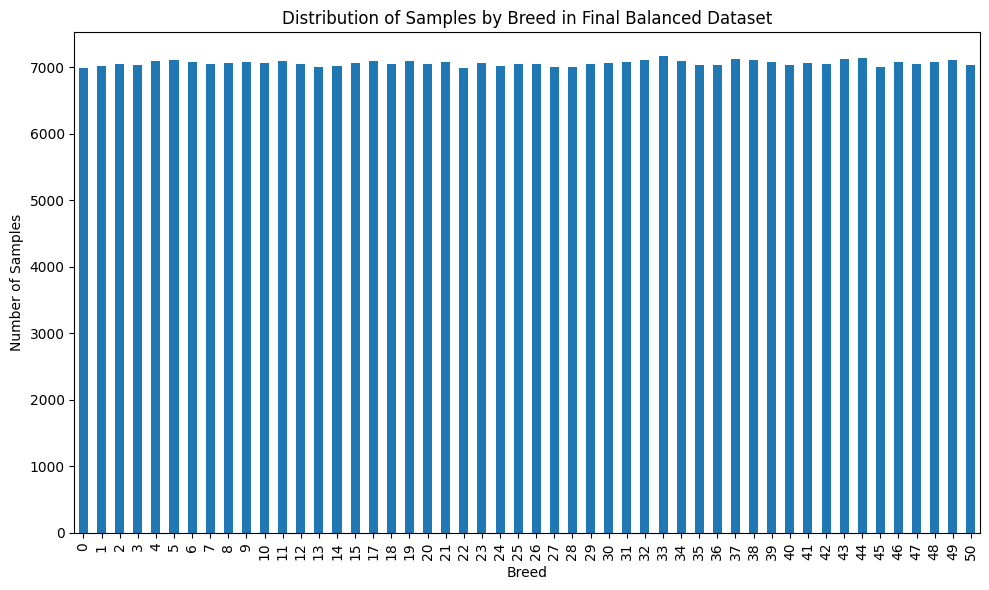

In [10]:
import matplotlib.pyplot as plt

# Group final_balanced_df by 'breed' and count the number of samples per breed.
# breed_counts = final_balanced_df[final_balanced_df['Breed'] == 'ML105'].groupby(['Year']).size()
breed_counts = train_df.groupby(['class_label']).size()

# Create a bar chart.
plt.figure(figsize=(10, 6))
breed_counts.plot(kind='bar')
plt.xlabel('Breed')
plt.ylabel('Number of Samples')
plt.title('Distribution of Samples by Breed in Final Balanced Dataset')
plt.tight_layout()
plt.show()


In [12]:
breed_counts

class_label
0     1544
1     1565
2     1562
3     1561
4     1547
5     1560
6     1544
7     1572
8     1566
9     1576
10    1575
11    1558
12    1583
13    1536
14    1583
15    1578
17    1584
18    1527
19    1573
20    1605
21    1586
22    1556
23    1583
24    1539
25    1552
26    1588
27    1581
28    1575
29    1570
30    1582
31    1556
32    1526
33    1554
34    1550
35    1598
36    1556
37    1587
38    1565
39    1564
40    1585
41    1593
42    1555
43    1578
44    1575
45    1579
46    1551
47    1560
48    1558
49    1556
50    1554
dtype: int64

In [11]:
breed_counts = valid_df.groupby(['class_label']).size()

In [12]:
breed_counts

class_label
0     1830
1     1812
2     1768
3     1787
4     1727
5     1718
6     1743
7     1776
8     1755
9     1751
10    1755
11    1733
12    1769
13    1825
14    1805
15    1757
17    1723
18    1768
19    1732
20    1769
21    1751
22    1834
23    1763
24    1800
25    1779
26    1772
27    1814
28    1814
29    1772
30    1757
31    1745
32    1721
33    1657
34    1729
35    1788
36    1793
37    1704
38    1718
39    1751
40    1788
41    1760
42    1770
43    1706
44    1677
45    1824
46    1749
47    1781
48    1739
49    1717
50    1794
dtype: int64

In [13]:
output_csv = "data/multiple_51class"
os.makedirs(output_csv, exist_ok=True)

In [14]:
final_balanced_df.to_csv(output_csv+ 'final_balanced_df.csv',index=False)
train_df.to_csv(output_csv + 'train_balanced_df.csv',index=False)
valid_df.to_csv(output_csv + 'valid_balanced_df.csv',index=False)

In [15]:
from tqdm import tqdm

In [16]:
import os
import numpy as np
import pandas as pd

# def load_data_from_npz(metadata_df, npz_dir):
#     total_images = len(metadata_df)  # Total number of images
#     # Preallocate arrays for images and labels
#     x = np.empty((total_images, 224, 224, 3), dtype=np.uint8)
#     y = np.empty((total_images,), dtype=object)  # or use dtype=str if appropriate

#     current_index = 0
#     grouped = metadata_df.groupby('keys_img_id_ac')
    
#     for key, group in tqdm(grouped):
#         file_name = f"{key}_train.npz"
#         file_path = os.path.join(npz_dir, file_name)
        
#         if not os.path.exists(file_path):
#             print(f"Warning: File {file_path} not found. Skipping this group.")
#             continue
        
#         npz_data = np.load(file_path)
#         images_array = npz_data["kernel_pics"].astype(np.uint8)
        
#         for idx in group["local_image_index"]:
#             idx = int(idx)
#             if idx < 0 or idx >= images_array.shape[0]:
#                 print(f"Warning: local_image_index {idx} out of range for file {file_path}. Skipping.")
#                 continue
            
#             # Directly fill the preallocated array
#             x[current_index] = images_array[idx]
#             y[current_index] = key
#             current_index += 1
#     print(current_index)
#     # In case some images were skipped, trim the arrays to the actual count.
#     x = x[:current_index]
#     y = y[:current_index]
    
#     return x, y


import os
import numpy as np
import pandas as pd
from tqdm import tqdm

def load_data_from_npz(metadata_df, npz_dir, split):
    generated_uuids = set()
    # Total number of images = original images + extra samples
    # orig_total = len(metadata_df)
    # total_images = orig_total + extra_sample_total

    # Preallocate arrays for images and labels.
    # All images are 224x224x3 in uint8.
    # x = np.empty((total_images, 224, 224, 3), dtype=np.uint8)
    # y = np.empty((total_images,), dtype=object)
    MP_TH_FOLDER = f"Images_MP_TH/{split}"
    os.makedirs(MP_TH_FOLDER, exist_ok=True)

    current_index = 0

    # === Part 1: Process original metadata ===
    grouped = metadata_df.groupby('keys_img_id_ac')
    for key, group in tqdm(grouped, desc="Processing original metadata"):
        breed = group['Breed'].iloc[0]
        os.makedirs(os.path.join(MP_TH_FOLDER, breed), exist_ok=True)
        file_name = f"{key}_train.npz"
        file_path = os.path.join(npz_dir, file_name)
        
        if not os.path.exists(file_path):
            print(f"Warning: File {file_path} not found. Skipping this group.")
            continue
        
        npz_data = np.load(file_path)
        images_array = npz_data["kernel_pics"].astype(np.uint8)
        
        for idx, image_array in zip(group["local_image_index"], images_array):
            idx = int(idx)
            if idx < 0 or idx >= images_array.shape[0]:
                print(f"Warning: local_image_index {idx} out of range for file {file_path}. Skipping.")
                continue
                
            image = image_array
            image_pil = Image.fromarray((image).astype(np.uint8)) 
            unique_id = uuid.uuid4().hex
            # Ensure that the UUID is unique.
            while unique_id in generated_uuids:
                unique_id = uuid.uuid4().hex
            generated_uuids.add(unique_id)
            image_pil.save(os.path.join(MP_TH_FOLDER, breed, f"{key}_{unique_id}.png"))
            
            # x[current_index] = images_array[idx]
            # # For original data, we keep the label as the key from metadata_df.
            # y[current_index] = key
            # current_index += 1

    # orig_loaded = current_index
    # print(f"Original images loaded: {orig_loaded}")

    # add_path_gk79 = '/media/nas/MP/data_pytorch/train/gk79_train_keys_img_id_ac/'
    
    # npz_files = [f for f in os.listdir(add_path_gk79) if f.endswith('.npz')]
    # total_npz_files = len(npz_files)
    # if total_npz_files == 0:
    #     print("No npz files found in directory for extra sampling.")
    #     # Trim the arrays to the actual number of loaded images.
    #     x = x[:current_index]
    #     y = y[:current_index]
    #     return x, y, metadata_df

    # # Calculate how many samples per file.
    # sample_per_file = extra_sample_total // total_npz_files
    # extra_metadata_rows = []

    # for npz_file in tqdm(npz_files, desc="Processing extra sampling"):
    #     file_path = os.path.join(add_path_gk79, npz_file)
    #     npz_data = np.load(file_path)
    #     images_array = npz_data["kernel_pics"].astype(np.uint8)
    #     available = images_array.shape[0]
        
    #     # Determine the number of samples for this file.
    #     n_samples = min(sample_per_file, available)
    #     if n_samples <= 0:
    #         continue
        
    #     # Randomly choose n_samples indices (without replacement).
    #     sampled_indices = np.random.choice(available, size=n_samples, replace=False)
        
    #     for idx in sampled_indices:
    #         # Check if we have reached the preallocated capacity.
    #         if current_index >= total_images:
    #             break

    #         x[current_index] = images_array[idx]
            
    #         label = npz_file.replace('.npz', '')
    #         y[current_index] = label

    #         # Save the metadata for this extra sample.
    #         extra_metadata_rows.append({
    #             'keys_img_id_ac': label,
    #             'local_image_index': int(idx)
    #         })
    #         current_index += 1

    # total_loaded = current_index
    # print(f"Total images loaded (original + extra): {total_loaded}")

    # # Trim arrays to the actual count.
    # x = x[:current_index]
    # y = y[:current_index]
    
    # # Create a DataFrame for the extra metadata.
    # extra_metadata_df = pd.DataFrame(extra_metadata_rows)
    # # Combine with the original metadata.
    # combined_metadata_df = pd.concat([metadata_df, extra_metadata_df], ignore_index=True)
    
    # return x, y, combined_metadata_df




def process_train_valid(npz_dir, train_metadata_df, valid_metadata_df):
    
    load_data_from_npz(train_metadata_df, npz_dir, split = "train")
    load_data_from_npz(valid_metadata_df, npz_dir, split = "valid")


train_metadata_df = pd.read_csv(output_csv + 'train_balanced_df.csv')
valid_metadata_df = pd.read_csv(output_csv + 'valid_balanced_df.csv')

# Define the directory where the npz files are stored.
npz_dir = "/media/nas/MP/hovernet/Split_Processed/Training_set/"

# Load the data.
process_train_valid(npz_dir, train_metadata_df, valid_metadata_df)
# print("x_train shape:", x_train.shape)
# print("x_valid shape:", x_valid.shape)

# train_metadata_df_add.to_csv(output_csv + 'train_balanced_df_add.csv',index=False)
# valid_metadata_df_add.to_csv(output_csv + 'valid_balanced_df_add.csv',index=False)


Processing original metadata: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 377/377 [12:34<00:00,  2.00s/it]


In [17]:
import os

TRAIN_MP_TH_FOLDER = "Images_MP_TH/train/"
image_extensions = {".jpg", ".jpeg", ".png"}
image_stats = {}

for root, _, files in os.walk(TRAIN_MP_TH_FOLDER):
    count = sum(1 for file in files if file.lower().endswith(tuple(image_extensions)))
    if count > 0:  # Only include folders that contain images
        subfolder = os.path.relpath(root, TRAIN_MP_TH_FOLDER)  # Get relative path
        image_stats[subfolder] = count

# Print statistics
for subfolder, count in image_stats.items():
    print(f"{subfolder}: {count} images")

# Optionally, print total count
total_images = sum(image_stats.values())
print(f"Total images across all subdirectories: {total_images}")



SPT1: 7054 images
ML105: 6993 images
GK45: 7078 images
PL80: 7102 images
HY71: 7054 images
GK57: 7044 images
GK79: 7080 images
GK41: 7072 images
CN1: 7055 images
GK87: 7068 images
CN2: 7060 images
RBR: 7100 images
GK47: 7009 images
GK29: 7051 images
ET: 6989 images
CMJ: 7029 images
GK52: 7042 images
GK16: 7053 images
PL2: 7036 images
LNP: 7074 images
GK20: 7091 images
HP5: 7018 images
GK10: 7090 images
GK31: 7166 images
JLSPT: 7035 images
GK15: 7011 images
GK12: 7055 images
AYTY1: 7066 images
GK61: 3529 images
GK71: 7009 images
SKNK: 7066 images
JKC: 7072 images
PT1: 7096 images
GK49: 7105 images
MF62: 7146 images
KS62: 7063 images
GK81: 7051 images
GK6: 3518 images
GVG1: 7084 images
NKK8974: 7106 images
GK33: 7105 images
SP1: 7094 images
DD20: 6999 images
TTCP: 7119 images
GK22: 6998 images
STJ8: 7030 images
GK85: 7023 images
GK43: 7035 images
GK18: 7072 images
MJ2: 7068 images
GK65: 7117 images
Total images across all subdirectories: 353080


In [18]:
import os

TRAIN_MP_TH_FOLDER = "Images_MP_TH/valid/"
image_extensions = {".jpg", ".jpeg", ".png"}
image_stats = {}

for root, _, files in os.walk(TRAIN_MP_TH_FOLDER):
    count = sum(1 for file in files if file.lower().endswith(tuple(image_extensions)))
    if count > 0:  # Only include folders that contain images
        subfolder = os.path.relpath(root, TRAIN_MP_TH_FOLDER)  # Get relative path
        image_stats[subfolder] = count

# Print statistics
for subfolder, count in image_stats.items():
    print(f"{subfolder}: {count} images")

# Optionally, print total count
total_images = sum(image_stats.values())
print(f"Total images across all subdirectories: {total_images}")

SPT1: 1769 images
ML105: 1830 images
GK45: 1745 images
PL80: 1721 images
HY71: 1769 images
GK57: 1779 images
GK79: 1743 images
GK41: 1751 images
CN1: 1768 images
GK87: 1755 images
CN2: 1763 images
RBR: 1723 images
GK47: 1814 images
GK29: 1772 images
ET: 1834 images
CMJ: 1794 images
GK52: 1781 images
GK16: 1770 images
PL2: 1787 images
LNP: 1749 images
GK20: 1732 images
HP5: 1805 images
GK10: 1733 images
GK31: 1657 images
JLSPT: 1788 images
GK15: 1812 images
GK12: 1768 images
AYTY1: 1757 images
GK61: 908 images
GK71: 1814 images
SKNK: 1757 images
JKC: 1751 images
PT1: 1727 images
GK49: 1718 images
MF62: 1677 images
KS62: 1760 images
GK81: 1772 images
GK6: 868 images
GVG1: 1739 images
NKK8974: 1717 images
GK33: 1718 images
SP1: 1729 images
DD20: 1824 images
TTCP: 1704 images
GK22: 1825 images
STJ8: 1793 images
GK85: 1800 images
GK43: 1788 images
GK18: 1751 images
MJ2: 1755 images
GK65: 1706 images
Total images across all subdirectories: 88070


In [ ]:
grouped_df

In [ ]:
npz_dir = "/media/nas/MP/hovernet/Split_Processed/Training_set/"

In [ ]:
import os
import numpy as np

def save_train_valid_data(x_train, y_train, x_valid, y_valid, output_dir):
    
    # Create the output directory if it doesn't exist.
    os.makedirs(output_dir, exist_ok=True)
    
    train_file = os.path.join(output_dir, "train_data.npz")
    valid_file = os.path.join(output_dir, "valid_data.npz")
    
    np.savez_compressed(train_file, x_train=x_train, y_train=y_train)
    np.savez_compressed(valid_file, x_valid=x_valid, y_valid=y_valid)
    
    print(f"Training data saved to: {train_file}")
    print(f"Validation data saved to: {valid_file}")

# ===== Example Usage =====
# Assuming x_train, y_train, x_valid, y_valid have been loaded already:
output_dir = "data/multiple_51class/"
os.makedirs(output_dir, exist_ok=True)
save_train_valid_data(x_train, y_train, x_valid, y_valid, output_dir)


Training data saved to: /workspace/media/nas/MP/hovernet/Split_Processed/multiple_7class_mali_gk79_gk6_pt1_pl80_cn1_spt1_version2/train_data.npz
Validation data saved to: /workspace/media/nas/MP/hovernet/Split_Processed/multiple_7class_mali_gk79_gk6_pt1_pl80_cn1_spt1_version2/valid_data.npz
